### Titanic: Deep Learning from Disaster

### Import libraries

### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|
| `matplotlib` | Görselleştirme |
| `numpy` | Sayısal hesaplamalar |
| `pandas` | Veri analizi |
| `seaborn` | İstatistiksel grafikler |


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Load Data

### Veri Setinin Yüklenmesi

Veri setini yükleyip temel bilgilerine bakıyoruz.

In [30]:
df_train = pd.read_csv('ttrain.csv')
df_test = pd.read_csv('ttest.csv')

In [31]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [32]:
df=pd.concat([df_train,df_test])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Temel İstatistikler

Verinin yapısını, eksik değerleri ve temel istatistikleri inceliyoruz.

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 132.9+ KB


### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [34]:
df.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [35]:
df['Title']=df['Name'].str.extract('([A-Za-z]+)\.')
df['Title']=df['Title'].replace(['Ms','Mlle'],'Miss')
df['Title']=df['Title'].replace(['Mme','Countess','Lady','Dona'],'Mrs')
df['Title']=df['Title'].replace(['Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer'],'Mr')

### Veri Gruplama ve Analiz

Verileri kategorilere göre gruplayıp analiz ediyoruz.

In [36]:
df['Title'].value_counts()

Title
Mr        783
Miss      264
Mrs       201
Master     61
Name: count, dtype: int64

### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [37]:
df['Age']=df['Age'].fillna(df.groupby('Title')['Age'].transform('mean'))

### Temel İstatistikler

Verinin yapısını, eksik değerleri ve temel istatistikleri inceliyoruz.

In [38]:
df['Fare'].describe()

count    1308.000000
mean       33.295479
std        51.758668
min         0.000000
25%         7.895800
50%        14.454200
75%        31.275000
max       512.329200
Name: Fare, dtype: float64

In [39]:
df['Fare'].median()

14.4542

### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [40]:
df['Fare'].fillna(df['Fare'].mode()[0],inplace=True)

### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [41]:
df['Fare'].isnull().sum()

0

### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [42]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode())

### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [43]:
df.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1014
Embarked          2
Title             0
dtype: int64

In [44]:
X=df.drop(['PassengerId','Survived','Name','Ticket','Cabin'],axis=1)
y=df['Survived']
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,3,male,22.0,1,0,7.2500,S,Mr
1,1,female,38.0,1,0,71.2833,C,Mrs
2,3,female,26.0,0,0,7.9250,S,Miss
3,1,female,35.0,1,0,53.1000,S,Mrs
4,3,male,35.0,0,0,8.0500,S,Mr


In [45]:
X=pd.get_dummies(X,drop_first=True)

### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [46]:
X.isnull().sum()

Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
Title_Miss    0
Title_Mr      0
Title_Mrs     0
dtype: int64

### Temel İstatistikler

Verinin yapısını, eksik değerleri ve temel istatistikleri inceliyoruz.

In [47]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      1309 non-null   int64  
 1   Age         1309 non-null   float64
 2   SibSp       1309 non-null   int64  
 3   Parch       1309 non-null   int64  
 4   Fare        1309 non-null   float64
 5   Sex_male    1309 non-null   bool   
 6   Embarked_Q  1309 non-null   bool   
 7   Embarked_S  1309 non-null   bool   
 8   Title_Miss  1309 non-null   bool   
 9   Title_Mr    1309 non-null   bool   
 10  Title_Mrs   1309 non-null   bool   
dtypes: bool(6), float64(2), int64(3)
memory usage: 69.0 KB


### change datatype bool to int

In [48]:
#change datatype bool to int
X['Sex_male']=X['Sex_male'].astype(int)
X['Embarked_Q']=X['Embarked_Q'].astype(int)
X['Embarked_S']=X['Embarked_S'].astype(int)
X['Title_Miss']=X['Title_Miss'].astype(int)
X['Title_Mr']=X['Title_Mr'].astype(int)
X['Title_Mrs']=X['Title_Mrs'].astype(int)

In [49]:
X_train=X[:891]
X_test=X[891:]
y_train=y[:891]
y_test=y[891:]

### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|
| `sklearn` | Makine öğrenmesi |


In [50]:
from sklearn.preprocessing import StandardScaler
scaled=StandardScaler()
X_train=scaled.fit_transform(X_train)
X_test=scaled.transform(X_test)

### Model Building

### pip install tensorflow

In [51]:
#pip install tensorflow

### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|
| `tensorflow` | Derin öğrenme |


In [52]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### Sinir Ağı Modeli

Derin öğrenme modeli oluşturup eğitiyoruz.

In [57]:
model = Sequential()
model.add(Dense(120, activation='relu'))
model.add(Dense(64, activation='relu'))
#add dropout layer
model.add(tf.keras.layers.Dropout(0.2))
model.add(Dense(6, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy',
              optimizer='adam',metrics=['accuracy'])

### Model Eğitimi

Modeli eğitim verisi üzerinde eğitip test verisi üzerinde değerlendiriyoruz.

In [58]:
history=model.fit(X_train,y_train,epochs=5,batch_size=32,validation_split=.20,verbose=1)

Epoch 1/5
23/23 [==============================] - 2s 24ms/step - loss: 0.6734 - accuracy: 0.6531 - val_loss: 0.6211 - val_accuracy: 0.8268
Epoch 2/5
23/23 [==============================] - 0s 12ms/step - loss: 0.6072 - accuracy: 0.7739 - val_loss: 0.5655 - val_accuracy: 0.8492
Epoch 3/5
23/23 [==============================] - 0s 11ms/step - loss: 0.5608 - accuracy: 0.8034 - val_loss: 0.5028 - val_accuracy: 0.8603
Epoch 4/5
23/23 [==============================] - 0s 9ms/step - loss: 0.5071 - accuracy: 0.8104 - val_loss: 0.4311 - val_accuracy: 0.8659
Epoch 5/5
23/23 [==============================] - 0s 8ms/step - loss: 0.4533 - accuracy: 0.8258 - val_loss: 0.3674 - val_accuracy: 0.8603


### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|
| `matplotlib` | Görselleştirme |


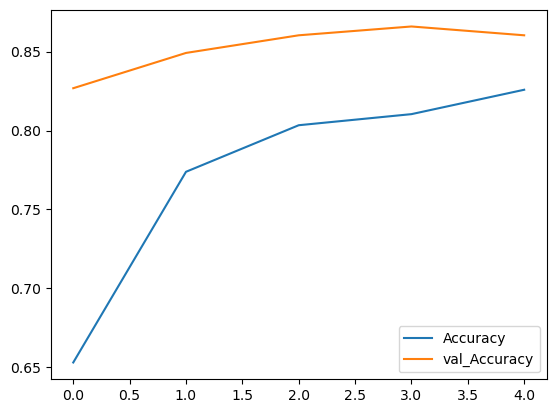

In [59]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='val_Accuracy')
plt.legend()

In [60]:
df_test['PassengerId'].shape

(418,)

In [61]:
y_pred = model.predict(X_test)

14/14 [==============================] - 0s 2ms/step


### y_pred

In [62]:
#y_pred

### comvert y_pred 0 or 1 if >0.5 then 1 else 0

In [63]:
#comvert y_pred 0 or 1 if >0.5 then 1 else 0
y_pred = np.where(y_pred > 0.5, 1, 0)

In [64]:
y_pred=y_pred.flatten()

In [65]:
submission = pd.DataFrame({
        "PassengerId": df_test["PassengerId"],
        "Survived": y_pred.astype(int)
    })
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [66]:
submission.to_csv('titanic_dl-1.csv', index=False)